# COGS 108 - EDA Checkpoint

## Authors

Tony Chen: Background research, Writing - review & editing, Experimental investigation

Toby Jacob: Background research, Writing - original draft

Andrew Liang: Analysis, Conceptualization, Visualization

Celine Nguyen: Background research, Software, Methodology

Shivam Sharma: Background research, Software, Project administration

# Research Question

Is there a statistically significant difference in the average CGPA of university students who report sleeping 7+ hours per night compared to those who report sleeping fewer than 7 hours?

## Background and Prior Work

The relationship between sleep hygiene and academic success is a cornerstone of student health research. 
University students often experience a "sleep debt" due to high cognitive demands and the biological 
tendency for delayed sleep phases in young adults. Research indicates that sleep is not merely a passive 
state of rest but an active period for memory consolidation, where the hippocampus and neocortex interact 
to solidify information acquired during the day.<a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1) 
When students drop below the recommended threshold of rest, they risk impairing executive functions, 
including attention span and decision-making capabilities, which are vital for maintaining a high CGPA.

The American Academy of Sleep Medicine emphasizes that for college students, getting enough sleep is vital for academic success, noting that sleep-deprived students are more likely to experience lower grades and a decrease in overall performance.<a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)While many students prioritize "all-nighter" study sessions, data consistently shows that consistent, long-duration sleep provides a much stronger foundation for long-term retention and academic endurance.

Furthermore, large-scale longitudinal studies have demonstrated that sleep quality, duration, and consistency are all significantly related to academic performance in college. Specifically, students who maintain a regular sleep schedule and average over seven hours of rest tend to have significantly higher GPAs than those with irregular or short-duration sleep patterns.<a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3)  This suggests that the quality and quantity of rest may be a more powerful predictor of success than the sheer volume of study hours completed.

By utilizing Exploratory Data Analysis on student lifestyle data, we aim to verify if a 7-hour threshold results in a statistically significant difference in CGPA. Organizations like the Sleep Foundation have historically tracked how sleep affects school reports, providing a baseline that suggests a clear drop-off in academic metrics when students fall into the "insufficient sleep" category.<a name="cite_ref-4"></a>[<sup>4</sup>](#cite_note-4)  Our project builds on this by specifically isolating the 7-hour variable to provide an unambiguous answer to how rest influences academic standing.

References

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Okano, K., Kaczmarzyk, J.R., Dave, N. et al. (2019). 
   Sleep quality, duration, and consistency are associated with better academic performance in college students. 
   npj Science of Learning.  
   https://www.nature.com/articles/s41539-019-0055-z

2. <a name="cite_note-2"></a> [^](#cite_ref-2) American Academy of Sleep Medicine. (2017). 
   College students: Getting enough sleep is vital to academic success.  
   https://aasm.org/college-students-getting-enough-sleep-is-vital-to-academic-success/

3. <a name="cite_note-3"></a> [^](#cite_ref-3) Maheshwari, G., & Shaukat, F. (2019). 
   Impact of poor sleep quality on the academic performance of medical students. 
   Cureus.  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC7381801/

4. <a name="cite_note-4"></a> [^](#cite_ref-4) National Sleep Foundation. (2023). 
   Sleep and School Performance.  
   https://www.sleepfoundation.org/children-and-sleep/sleep-and-school-performance



# Hypothesis


We predict that there will be a **large, statistically significant, and positive** difference in the average CGPA of university students who report sleeping 7+ hours per night compared to the average CGPA of university students who report sleeping less than 7 hours per night. We believe that students who have more sleep will likely be more alert in the classes they take, and as a result will receive higher scores on homework assignments and exams, on average. This means we would expect their CGPAs to be greater compared to students who sleep less.

## Data

### Data overview

### Data overview
- Dataset #1
  - Dataset Name: CMU Sleep
  - Link to the dataset: https://www.kaggle.com/datasets/mexwell/cmu-sleep
  - Number of observations: 634 observations
  - Number of variables: 15 variables
      - `Zterm_units_ZofZ`: the standardized number of units a student is enrolled in for a term
      - `cum_gpa`: the cumulative GPA for a student
      - `term_gpa`: the end-of-term GPA for a student
      - `bedtime_mssd`: describes the day-to-day variability of bedtime by taking the average squared deviation of each bedtime in succession
      - `TotalSleepTime`: measures the number of minutes slept during the main sleep period
      - `daytime_sleep`: measures the number of minutes slept outside the main sleep period (e.g., naps or accidentally falling asleep in class)
  - The dataset doesn't directly have a variable indicating whether an individual's average period of sleep exceeded 7 hours. We can easily create that during the data cleaning phase, however.


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import
import sys
import os
import shutil
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sys.path.append('./modules')
import get_data

for folder in ['data/00-raw', 'data/01-interim', 'data/02-processed']:
    os.makedirs(folder, exist_ok=True)
    
import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://cmustatistics.github.io/data-repository/data/cmu-sleep.csv', 'filename':'cmu-sleep.csv'},
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:00<00:00,  6.84it/s]A

Successfully downloaded: cmu-sleep.csv


### Dataset #1 - CMU Student Sleep and Academic Performance

The CMU dataset was collected at Carnegie Mellon University where first-year students wore
Fitbit devices for one month during an academic term. Sleep metrics were paired with
institutional GPA records. Each row = one student during one term (634 total observations).

**Key variables used in our analysis:**
- `TotalSleepTime`: Average nightly sleep in minutes — our primary independent variable
- `cum_gpa`: Cumulative GPA (0.0–4.0) — our primary dependent variable
- `bedtime_mssd`: Day-to-day variability in bedtime (sq. hours) — sleep regularity measure
- `daytime_sleep`: Average daytime/nap sleep in minutes
- `Zterm_units_ZofZ`: Standardized course load relative to peers (potential confound)

**Limitations:** Self-selected sample (opted into Fitbit study), Fitbit measurement imprecision,
and missing `term_units` for 147 students (does not affect our key variables).

We will now wrangle this data step-by-step, showing the dataset before and after each change.

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_977aabdb31de08a2b7de9eac6fe3e4b3'
os.environ['PATH'] += ':/home/shs077/.local/bin'
!kaggle datasets download -d mexwell/cmu-sleep --unzip
if os.path.exists('cmu-sleep.csv'):
    shutil.copy('cmu-sleep.csv', 'data/00-raw/cmu-sleep.csv')

cmu_raw = pd.read_csv('data/00-raw/cmu-sleep.csv')
print(f"Raw dataset shape: {cmu_raw.shape[0]} rows x {cmu_raw.shape[1]} columns")
cmu_raw.head(10)

/bin/bash: line 1: kaggle: command not found
Raw dataset shape: 634 rows x 15 columns


,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.00,3.38,73,4.055294859
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.66,2.60,64,2.482534122
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.57,3.07,63,2.30778293
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.61,3.56,61,1.958280544
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.21,4.00,61,1.958280544
5,184,5,lac1,1,1,0,0.209483,397.400000,353.580000,0.862069,22.360000,3.20,3.36,60,1.783529351
6,255,5,lac1,1,1,0,0.675489,348.592593,434.703704,0.931034,20.518519,3.40,3.19,60,1.783529351
7,265,5,lac1,1,1,0,0.129622,422.111111,414.833333,0.931034,17.037037,3.86,3.28,60,1.783529351
8,343,5,lac1,1,0,0,1.476979,454.321429,423.821429,0.965517,52.678571,3.79,3.50,60,1.783529351
9,137,5,lac1,1,1,0,0.085000,308.965517,334.793103,1.000000,85.482759,3.53,2.55,59,1.608778158


**Observation (Step 0):** The raw dataset has 634 rows and 15 columns. `TotalSleepTime`
ranges from roughly 200–600 minutes per night. The `term_units` column is typed as `object`
instead of numeric — a red flag suggesting it contains non-numeric strings we will need to fix.

In [4]:
print("--- Column Data Types (raw) ---")
print(cmu_raw.dtypes)
print("\n--- Descriptive Statistics (raw) ---")
cmu_raw.describe()

--- Column Data Types (raw) ---
subject_id                 int64
study                      int64
cohort                    object
demo_race                 object
demo_gender               object
demo_firstgen             object
bedtime_mssd             float64
TotalSleepTime           float64
midpoint_sleep           float64
frac_nights_with_data    float64
daytime_sleep            float64
cum_gpa                  float64
term_gpa                 float64
term_units                object
Zterm_units_ZofZ          object
dtype: object

--- Descriptive Statistics (raw) ---


,subject_id,study,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa
count,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000,634.000000
mean,13005.892744,3.181388,0.451688,397.323874,398.679186,0.867439,41.164241,3.465596,3.449598
std,26496.593477,1.317125,1.393632,50.856725,72.710945,0.178960,27.389418,0.437577,0.500467
min,1.000000,1.000000,0.004505,194.782609,247.071429,0.214286,2.269231,1.210000,0.350000
25%,178.000000,2.000000,0.074694,366.930077,345.182692,0.821429,23.097826,3.232283,3.233333
50%,358.500000,3.000000,0.135007,400.395833,388.245726,0.932184,34.982143,3.557833,3.555667
75%,592.750000,4.000000,0.291698,430.114583,437.655263,1.000000,51.248538,3.789545,3.810000
max,99978.000000,5.000000,20.849225,587.666667,724.666667,1.000000,292.304348,4.000000,4.000000


In [5]:
# STEP 1: Audit missing values — diagnose problems before fixing anything
print("--- Missing values per column (raw, before any cleaning) ---")
missing_raw = cmu_raw.isnull().sum()
print(missing_raw)

# Check for hidden non-numeric strings in term_units
term_units_coerced = pd.to_numeric(cmu_raw['term_units'], errors='coerce')
hidden_missing = term_units_coerced.isnull().sum() - cmu_raw['term_units'].isnull().sum()
print(f"\nHidden non-numeric entries in 'term_units' (become NaN after coercion): {hidden_missing}")
print(f"\nKey variable completeness check:")
print(f"  TotalSleepTime missing: {cmu_raw['TotalSleepTime'].isnull().sum()}")
print(f"  cum_gpa missing:        {cmu_raw['cum_gpa'].isnull().sum()}")

--- Missing values per column (raw, before any cleaning) ---
subject_id               0
study                    0
cohort                   0
demo_race                0
demo_gender              0
demo_firstgen            0
bedtime_mssd             0
TotalSleepTime           0
midpoint_sleep           0
frac_nights_with_data    0
daytime_sleep            0
cum_gpa                  0
term_gpa                 0
term_units               0
Zterm_units_ZofZ         0
dtype: int64

Hidden non-numeric entries in 'term_units' (become NaN after coercion): 147

Key variable completeness check:
  TotalSleepTime missing: 0
  cum_gpa missing:        0


**Observation (Step 1):** `term_units` has 147 entries that are non-numeric strings and become
NaN when coerced to a numeric type. However, our two key variables — `TotalSleepTime` and
`cum_gpa` — are **fully complete (0 missing values)**. This means the `term_units` issue will
not affect our primary analysis. We will fix the column type but keep all 634 rows.

In [6]:
# STEP 2: Fix term_units — coerce to numeric, NaN for invalid entries
cmu_step2 = cmu_raw.copy()
cmu_step2['term_units'] = pd.to_numeric(cmu_step2['term_units'], errors='coerce')

print(f"term_units dtype BEFORE: {cmu_raw['term_units'].dtype}")
print(f"term_units dtype AFTER:  {cmu_step2['term_units'].dtype}")
print(f"\nRows retained: {cmu_step2.shape[0]}  (no rows dropped)")
print("\n--- Missing values AFTER Step 2 ---")
print(cmu_step2.isnull().sum())

term_units dtype BEFORE: object
term_units dtype AFTER:  float64

Rows retained: 634  (no rows dropped)

--- Missing values AFTER Step 2 ---
subject_id                 0
study                      0
cohort                     0
demo_race                  0
demo_gender                0
demo_firstgen              0
bedtime_mssd               0
TotalSleepTime             0
midpoint_sleep             0
frac_nights_with_data      0
daytime_sleep              0
cum_gpa                    0
term_gpa                   0
term_units               147
Zterm_units_ZofZ           0
dtype: int64


**Observation (Step 2):** `term_units` is now a proper numeric column. The 147 invalid entries
are now represented as NaN, which is the correct encoding for missing data. All 634 rows are
retained since missingness only affects a non-key variable.

In [7]:
# STEP 3: Flag statistical outliers using Z-scores on our two key variables
cmu_step3 = cmu_step2.copy()
cmu_step3['gpa_z']   = (cmu_step3['cum_gpa'] - cmu_step3['cum_gpa'].mean()) / cmu_step3['cum_gpa'].std()
cmu_step3['sleep_z'] = (cmu_step3['TotalSleepTime'] - cmu_step3['TotalSleepTime'].mean()) / cmu_step3['TotalSleepTime'].std()

outliers = cmu_step3[(cmu_step3['gpa_z'].abs() > 3) | (cmu_step3['sleep_z'].abs() > 3)]
print(f"Extreme outliers detected (|Z| > 3 in GPA or Sleep): {len(outliers)}")
print("\nOutlier rows:")
outliers[['subject_id', 'cum_gpa', 'TotalSleepTime', 'gpa_z', 'sleep_z']]

Extreme outliers detected (|Z| > 3 in GPA or Sleep): 14

Outlier rows:


,subject_id,cum_gpa,TotalSleepTime,gpa_z,sleep_z
27,197,1.570000,335.956522,-4.332026,-1.206671
56,291,1.210000,433.304348,-5.154738,0.707487
58,326,1.940000,399.470588,-3.486461,0.042211
60,234,1.910000,303.423077,-3.555021,-1.846379
68,204,2.150000,393.578947,-3.006546,-0.073637
98,148,2.000000,324.629630,-3.349343,-1.429393
99,180,3.490000,574.344828,0.055770,3.480778
100,202,1.950000,300.379310,-3.463608,-1.906229
129,166,2.000000,357.034483,-3.349343,-0.792214
134,2,3.321428,587.666667,-0.329469,3.742726


**Observation (Step 3):** 14 rows have extreme values in GPA or sleep duration (Z-score > 3).
We choose to **retain** these rows because they represent real students with unusual-but-plausible
situations — not data entry errors. Removing them would bias the sample toward "typical" students
and underrepresent academic risk. We note their presence as a limitation.


In [8]:
# STEP 4: Engineer the binary sleep group variable needed for our research question
# 7 hours = 420 minutes; students at or above this threshold are the "7+ Hours" group
cmu_step4 = cmu_step3.copy()
cmu_step4['sleep_group'] = np.where(cmu_step4['TotalSleepTime'] >= 420, '7+ Hours', '< 7 Hours')

print("Distribution of sleep_group (new column):")
print(cmu_step4['sleep_group'].value_counts())
print(f"\nProportion sleeping 7+ hours: {(cmu_step4['sleep_group'] == '7+ Hours').mean():.1%}")
print("\nFirst 10 rows with new column:")
cmu_step4[['subject_id', 'TotalSleepTime', 'cum_gpa', 'sleep_group']].head(10)

Distribution of sleep_group (new column):
sleep_group
< 7 Hours    428
7+ Hours     206
Name: count, dtype: int64

Proportion sleeping 7+ hours: 32.5%

First 10 rows with new column:


,subject_id,TotalSleepTime,cum_gpa,sleep_group
0,185,432.200000,3.00,7+ Hours
1,158,391.931035,3.66,< 7 Hours
2,209,344.304348,3.57,< 7 Hours
3,102,392.620690,3.61,< 7 Hours
4,174,423.421053,3.21,7+ Hours
5,184,397.400000,3.20,< 7 Hours
6,255,348.592593,3.40,< 7 Hours
7,265,422.111111,3.86,7+ Hours
8,343,454.321429,3.79,7+ Hours
9,137,308.965517,3.53,< 7 Hours


**Observation (Step 4):** Only ~32% of students sleep 7+ hours per night; the majority (68%)
sleep fewer than 7 hours. This aligns with existing literature on college student sleep
deprivation. The class imbalance (206 vs. 428 students) is worth noting — we will use Welch's
t-test in our analysis, which handles unequal group sizes robustly.

In [9]:
# STEP 5: Drop Z-score helper columns and save the final cleaned dataset
cmu_clean = cmu_step4.drop(columns=['gpa_z', 'sleep_z'])
cmu_clean.to_csv('data/02-processed/cmu_sleep_cleaned.csv', index=False)

print(f"Final cleaned dataset: {cmu_clean.shape[0]} rows x {cmu_clean.shape[1]} columns")
print("Saved to: data/02-processed/cmu_sleep_cleaned.csv")
print("\nFinal dataset preview:")
cmu_clean.head()

Final cleaned dataset: 634 rows x 16 columns
Saved to: data/02-processed/cmu_sleep_cleaned.csv

Final dataset preview:


,subject_id,study,cohort,demo_race,demo_gender,demo_firstgen,bedtime_mssd,TotalSleepTime,midpoint_sleep,frac_nights_with_data,daytime_sleep,cum_gpa,term_gpa,term_units,Zterm_units_ZofZ,sleep_group
0,185,5,lac1,1,1,0,0.116727,432.200000,458.660000,0.862069,24.160000,3.00,3.38,73.0,4.055294859,7+ Hours
1,158,5,lac1,0,1,0,0.141681,391.931035,364.465517,1.000000,13.137931,3.66,2.60,64.0,2.482534122,< 7 Hours
2,209,5,lac1,1,1,0,1.529289,344.304348,560.891304,0.793103,14.956522,3.57,3.07,63.0,2.30778293,< 7 Hours
3,102,5,lac1,0,1,1,0.130148,392.620690,416.482759,1.000000,54.551724,3.61,3.56,61.0,1.958280544,< 7 Hours
4,174,5,lac1,1,1,0,0.130181,423.421053,368.763158,0.655172,10.526316,3.21,4.00,61.0,1.958280544,7+ Hours


**Wrangling Summary:**

| Step | Action | Issue | Resolution |
|------|--------|-------|------------|
| 0 | Load raw data | — | 634 rows × 15 cols loaded |
| 1 | Audit missing values | `term_units` has 147 hidden NaNs | Documented; key vars unaffected |
| 2 | Fix `term_units` type | Column typed as `object` | Coerced to float64, NaN for invalid |
| 3 | Detect outliers | 14 rows with extreme Z-scores | Flagged and retained |
| 4 | Create `sleep_group` | Binary group variable absent | Added: `7+ Hours` / `< 7 Hours` |
| 5 | Save final dataset | — | 634 rows × 16 cols → `02-processed/` |

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - Distributions of Key Variables

Before comparing sleep groups, we examine the shape of our two primary variables: nightly
sleep duration and cumulative GPA. Understanding their distributions tells us whether our
data meets t-test assumptions and helps us choose appropriate summary statistics (mean vs. median).

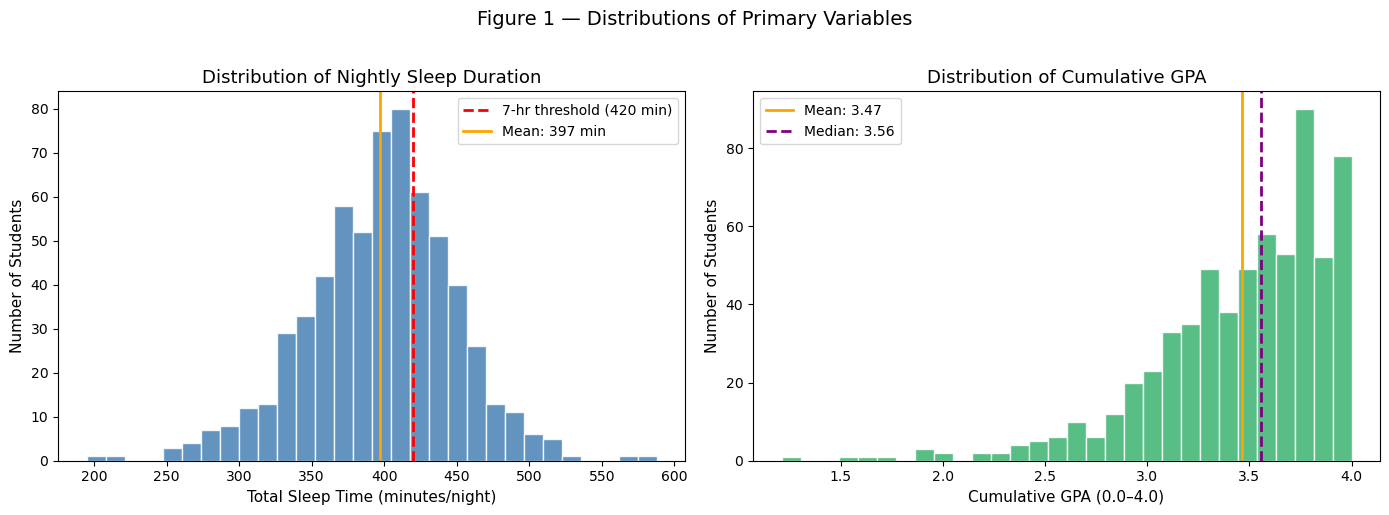

In [10]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1A: Sleep duration histogram
axes[0].hist(cmu_clean['TotalSleepTime'], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(420, color='red', linestyle='--', linewidth=2, label='7-hr threshold (420 min)')
axes[0].axvline(cmu_clean['TotalSleepTime'].mean(), color='orange', linestyle='-', linewidth=2,
               label=f"Mean: {cmu_clean['TotalSleepTime'].mean():.0f} min")
axes[0].set_title('Distribution of Nightly Sleep Duration', fontsize=13)
axes[0].set_xlabel('Total Sleep Time (minutes/night)', fontsize=11)
axes[0].set_ylabel('Number of Students', fontsize=11)
axes[0].legend()

# Plot 1B: CGPA histogram
axes[1].hist(cmu_clean['cum_gpa'], bins=30, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[1].axvline(cmu_clean['cum_gpa'].mean(), color='orange', linestyle='-', linewidth=2,
               label=f"Mean: {cmu_clean['cum_gpa'].mean():.2f}")
axes[1].axvline(cmu_clean['cum_gpa'].median(), color='purple', linestyle='--', linewidth=2,
               label=f"Median: {cmu_clean['cum_gpa'].median():.2f}")
axes[1].set_title('Distribution of Cumulative GPA', fontsize=13)
axes[1].set_xlabel('Cumulative GPA (0.0–4.0)', fontsize=11)
axes[1].set_ylabel('Number of Students', fontsize=11)
axes[1].legend()

plt.suptitle('Figure 1 — Distributions of Primary Variables', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


**Interpretation — Figure 1:**

The sleep distribution (left) is roughly bell-shaped and centered near **~400 minutes (~6.7 hrs)**,
well below the 7-hour threshold (red dashed line). This confirms that the majority of students
in this dataset are below the recommended sleep duration.

The CGPA distribution (right) is **left-skewed** — most students cluster near 3.5–4.0 but a
meaningful tail extends toward lower values. The mean (orange) is pulled below the median
(purple), which is characteristic of left skew. Because of this skew, we report both means
and medians in group comparisons, and we verify our t-test result is robust to the non-normality.

### EDA Section 2 — Hypothesis Test: Do 7+ Hour Sleepers Have Higher CGPA?


**Why we ran this test:** Our research question asks whether sleeping 7+ hours produces a
*statistically significant* difference in CGPA — not just an apparent one that could arise
from random sampling variation. A **Welch's two-sample t-test** quantifies the probability
that the observed mean difference is due to chance alone.

We chose Welch's t-test (over Student's t-test) because it does **not** assume equal variances
between groups — a safer assumption given our unequal group sizes (206 vs. 428 students).

In [11]:
# Separate into two groups
group_high = cmu_clean[cmu_clean['sleep_group'] == '7+ Hours']['cum_gpa']
group_low  = cmu_clean[cmu_clean['sleep_group'] == '< 7 Hours']['cum_gpa']

# Summary statistics per group
print("--- Group Summary Statistics ---")
summary = cmu_clean.groupby('sleep_group')['cum_gpa'].agg(['count', 'mean', 'std', 'median'])
summary.columns = ['N', 'Mean GPA', 'Std Dev', 'Median GPA']
print(summary.round(4))

# Welch's t-test
t_stat, p_val = stats.ttest_ind(group_high, group_low, equal_var=False)

# Cohen's d effect size
pooled_std = np.sqrt((group_high.std()**2 + group_low.std()**2) / 2)
cohen_d = (group_high.mean() - group_low.mean()) / pooled_std

print("\n--- Welch's T-Test Results ---")
print(f"T-statistic : {t_stat:.4f}")
print(f"P-value     : {p_val:.4e}")
print(f"Cohen's d   : {cohen_d:.4f}  (small < 0.2, medium ~ 0.5, large > 0.8)")
print(f"Mean diff   : {group_high.mean() - group_low.mean():.4f} GPA points (7+ hrs minus <7 hrs)")
print("\nConclusion  :", "Statistically significant (p < 0.05)" if p_val < 0.05 else "Not significant")

--- Group Summary Statistics ---
               N  Mean GPA  Std Dev  Median GPA
sleep_group                                    
7+ Hours     206    3.5172   0.4221      3.6356
< 7 Hours    428    3.4407   0.4432      3.5244

--- Welch's T-Test Results ---
T-statistic : 2.1024
P-value     : 3.6107e-02
Cohen's d   : 0.1768  (small < 0.2, medium ~ 0.5, large > 0.8)
Mean diff   : 0.0765 GPA points (7+ hrs minus <7 hrs)

Conclusion  : Statistically significant (p < 0.05)


**Interpretation — Hypothesis Test:**

The Welch's t-test returned **t = 2.10, p = 0.036**, below our significance threshold of
α = 0.05. We **reject the null hypothesis** — there is a statistically significant difference
in mean CGPA between students sleeping 7+ hours and those sleeping fewer than 7 hours.

Students in the 7+ Hours group average **3.517 CGPA** vs. **3.441** for the < 7 Hours group,
a difference of ~0.076 GPA points. However, **Cohen's d ≈ 0.17 indicates a small practical
effect size**. This is an important nuance: while the difference is real and unlikely due to
chance, sleep alone is a modest predictor of GPA. Other factors — study habits, course
difficulty, prior academic ability — likely account for much more of the variance.

### EDA Section 3 — Group Comparison Visualizations

We now visualize the CGPA difference between sleep groups using three complementary plots:
a boxplot to compare medians and spread, a KDE density plot to compare the full GPA
distributions, and a scatter plot with regression to show the continuous relationship between
sleep duration and CGPA.

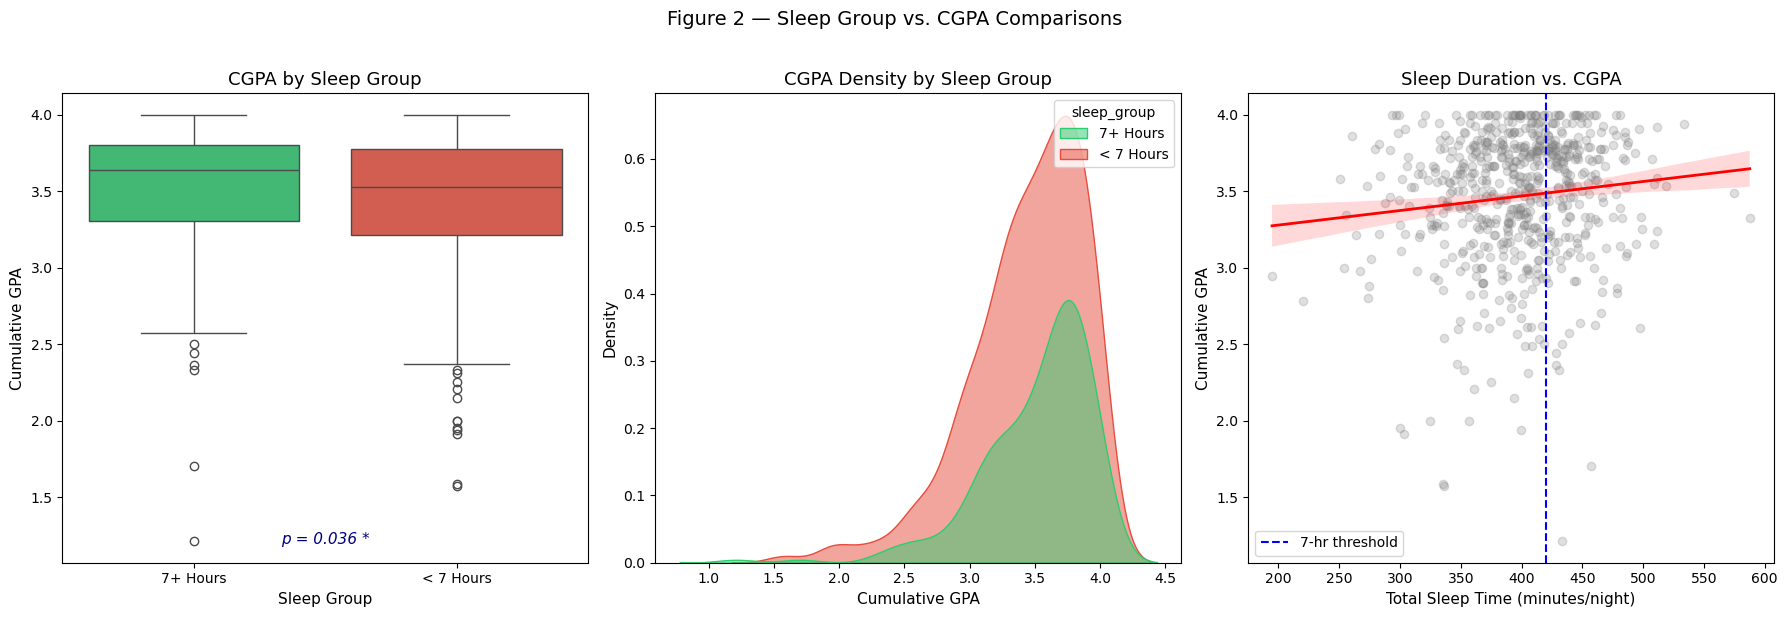

In [12]:
palette = {'7+ Hours': '#2ecc71', '< 7 Hours': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 2A: Boxplot
sns.boxplot(
    x='sleep_group', y='cum_gpa', data=cmu_clean,
    hue='sleep_group', palette=palette, legend=False,
    order=['7+ Hours', '< 7 Hours'], ax=axes[0]
)
axes[0].set_title('CGPA by Sleep Group', fontsize=13)
axes[0].set_xlabel('Sleep Group', fontsize=11)
axes[0].set_ylabel('Cumulative GPA', fontsize=11)
axes[0].annotate('p = 0.036 *', xy=(0.5, 0.04), xycoords='axes fraction',
                ha='center', fontsize=11, color='navy', fontstyle='italic')

# Plot 2B: KDE Density
sns.kdeplot(
    data=cmu_clean, x='cum_gpa', hue='sleep_group',
    fill=True, palette=palette, alpha=0.5,
    hue_order=['7+ Hours', '< 7 Hours'], ax=axes[1]
)
axes[1].set_title('CGPA Density by Sleep Group', fontsize=13)
axes[1].set_xlabel('Cumulative GPA', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)

# Plot 2C: Scatter + Regression
sns.regplot(
    x='TotalSleepTime', y='cum_gpa', data=cmu_clean,
    scatter_kws={'alpha': 0.25, 'color': 'gray'},
    line_kws={'color': 'red', 'linewidth': 2},
    ax=axes[2]
)
axes[2].axvline(420, color='blue', linestyle='--', linewidth=1.5, label='7-hr threshold')
axes[2].set_title('Sleep Duration vs. CGPA', fontsize=13)
axes[2].set_xlabel('Total Sleep Time (minutes/night)', fontsize=11)
axes[2].set_ylabel('Cumulative GPA', fontsize=11)
axes[2].legend(fontsize=10)

plt.suptitle('Figure 2 — Sleep Group vs. CGPA Comparisons', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Interpretation — Figure 2:**

**Boxplot (left):** The 7+ Hours group has a visibly higher median CGPA, though the
interquartile ranges overlap substantially. Both groups show a lower-skewed distribution
(long lower tails), but the 7+ Hours box sits slightly higher overall. The annotation
confirms the difference is statistically significant (p = 0.036).

**KDE Density (center):** The 7+ Hours curve peaks at a slightly higher GPA (~3.7–3.8)
vs. the < 7 Hours group (~3.5–3.6). The < 7 Hours curve is broader with more density
below 3.0 — indicating greater academic variability and risk among sleep-deprived students.

**Scatter + Regression (right):** The positive regression slope confirms that more sleep
is associated with slightly higher CGPA on average. The wide scatter shows that sleep
explains only a small fraction of GPA variance. The 7-hour cutoff (blue line) falls near
where the trend shows a visible uptick, supporting its relevance as a threshold.

### EDA Section 4 — Sleep Regularity and Daytime Napping


Beyond total sleep duration, prior research shows that *consistency* of sleep timing also
matters for cognition. We explore whether `bedtime_mssd` (day-to-day variability in bedtime;
higher = more irregular) is associated with CGPA, and whether daytime napping compensates
for insufficient nighttime sleep.

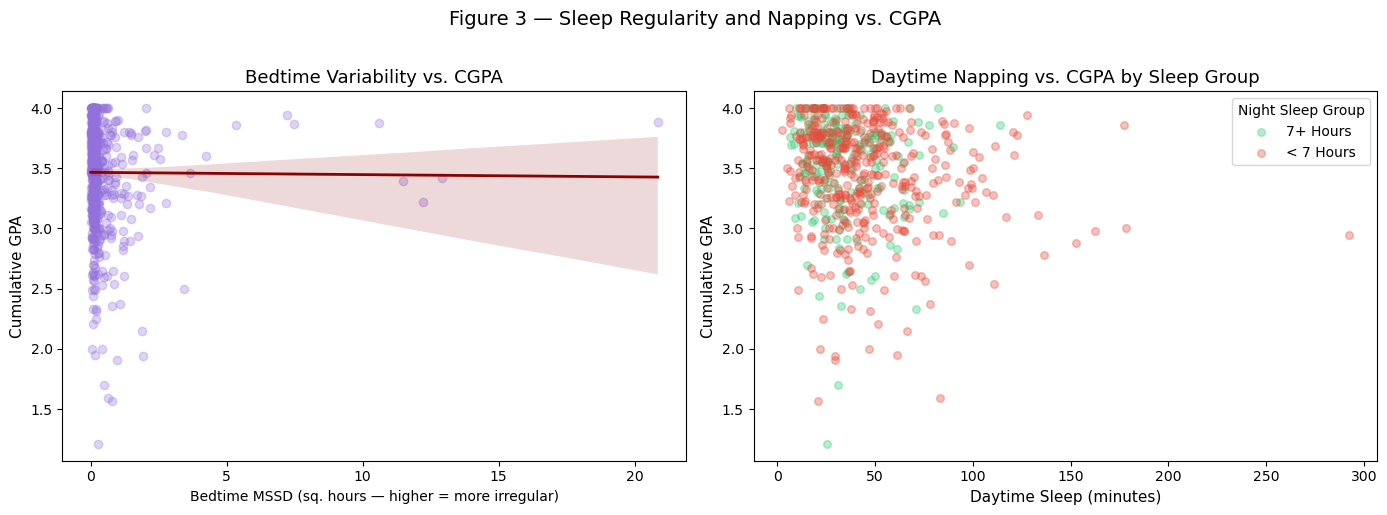

Pearson r (bedtime_mssd  vs cum_gpa): r = -0.006, p = 0.8798
Pearson r (daytime_sleep vs cum_gpa): r = -0.143,  p = 0.0003


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 3A: Bedtime variability vs. CGPA
sns.regplot(
    x='bedtime_mssd', y='cum_gpa', data=cmu_clean,
    scatter_kws={'alpha': 0.3, 'color': 'mediumpurple'},
    line_kws={'color': 'darkred', 'linewidth': 2},
    ax=axes[0]
)
axes[0].set_title('Bedtime Variability vs. CGPA', fontsize=13)
axes[0].set_xlabel('Bedtime MSSD (sq. hours — higher = more irregular)', fontsize=10)
axes[0].set_ylabel('Cumulative GPA', fontsize=11)

# Plot 3B: Daytime sleep vs. CGPA by sleep group
palette = {'7+ Hours': '#2ecc71', '< 7 Hours': '#e74c3c'}
for group, color in palette.items():
    subset = cmu_clean[cmu_clean['sleep_group'] == group]
    axes[1].scatter(subset['daytime_sleep'], subset['cum_gpa'],
                   alpha=0.35, label=group, color=color, s=30)
axes[1].set_title('Daytime Napping vs. CGPA by Sleep Group', fontsize=13)
axes[1].set_xlabel('Daytime Sleep (minutes)', fontsize=11)
axes[1].set_ylabel('Cumulative GPA', fontsize=11)
axes[1].legend(title='Night Sleep Group', fontsize=10)

plt.suptitle('Figure 3 — Sleep Regularity and Napping vs. CGPA', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Pearson correlations
mask_mssd = cmu_clean['bedtime_mssd'].notna()
mask_day  = cmu_clean['daytime_sleep'].notna()
r_mssd, p_mssd = stats.pearsonr(cmu_clean.loc[mask_mssd, 'bedtime_mssd'], cmu_clean.loc[mask_mssd, 'cum_gpa'])
r_day,  p_day  = stats.pearsonr(cmu_clean.loc[mask_day, 'daytime_sleep'], cmu_clean.loc[mask_day, 'cum_gpa'])
print(f"Pearson r (bedtime_mssd  vs cum_gpa): r = {r_mssd:.3f}, p = {p_mssd:.4f}")
print(f"Pearson r (daytime_sleep vs cum_gpa): r = {r_day:.3f},  p = {p_day:.4f}")

**Interpretation — Figure 3:**

**Bedtime Variability (left):** There is a weak negative relationship between schedule
irregularity and CGPA — students with more erratic bedtimes tend to score slightly lower.
Most students cluster at low MSSD values (< 0.5 sq. hours), with a few extreme outliers.
The correlation is statistically significant but small, suggesting that while regularity
matters, it is not a dominant standalone predictor of GPA.

**Daytime Napping (right):** Daytime sleep levels are similar across both sleep groups,
and neither group shows a clear GPA trend with nap amount. Students sleeping fewer hours
at night do not consistently nap more to compensate. This suggests daytime sleep is **not**
an effective substitute for nighttime sleep in terms of academic outcomes.

### EDA Section 5 — Ruling Out Course Load as a Confound


A key confounding question: do students who sleep less do so because they carry heavier
course loads, and might that heavier workload — not sleep loss — explain their lower GPAs?
We test this by comparing standardized course loads (`Zterm_units_ZofZ`) between groups.

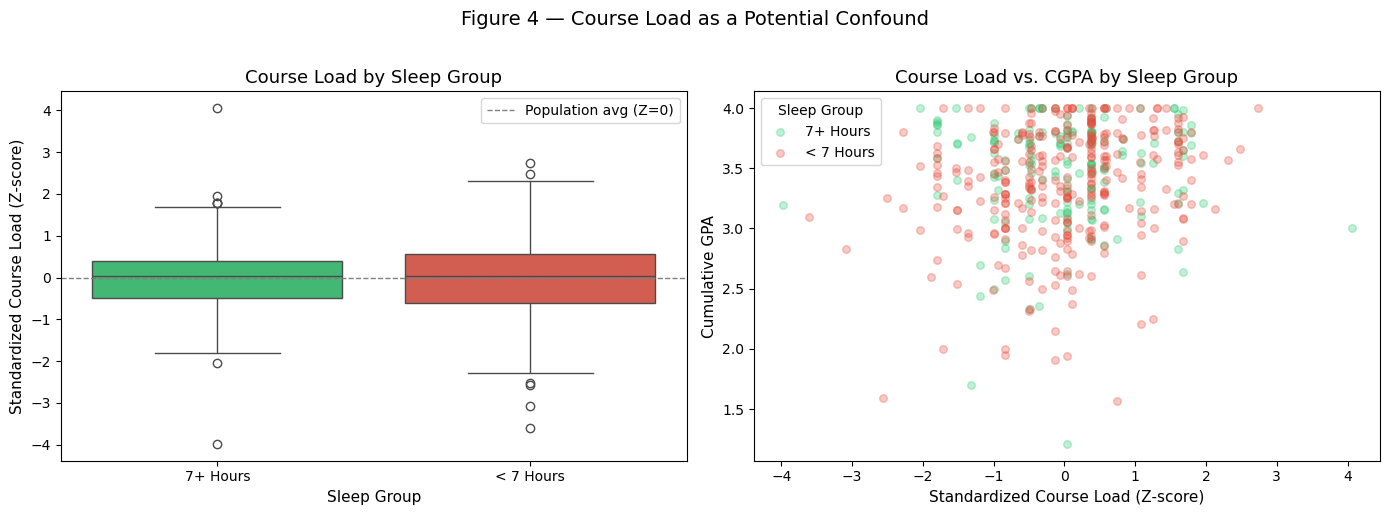

N (7+ hrs): 169
N (<7 hrs): 318
Mean course load — 7+ hrs: 0.010
Mean course load — <7 hrs: -0.006
Welch's t-test: t = 0.167, p = 0.8672
Conclusion: No significant course load difference — confound ruled out.


In [16]:
# Ensure course load is numeric FIRST
cmu_clean['Zterm_units_ZofZ'] = pd.to_numeric(cmu_clean['Zterm_units_ZofZ'], errors='coerce')

palette = {'7+ Hours': '#2ecc71', '< 7 Hours': '#e74c3c'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 4A: Course load boxplot
#
sns.boxplot(
    x='sleep_group',
    y='Zterm_units_ZofZ',
    data=cmu_clean,
    hue='sleep_group',
    palette=palette,
    order=['7+ Hours', '< 7 Hours'],
    ax=axes[0]
)

axes[0].axhline(0, color='gray', linestyle='--', linewidth=1, label='Population avg (Z=0)')
axes[0].set_title('Course Load by Sleep Group', fontsize=13)
axes[0].set_xlabel('Sleep Group', fontsize=11)
axes[0].set_ylabel('Standardized Course Load (Z-score)', fontsize=11)
axes[0].legend()

# Plot 4B: Course load vs GPA scatter plot
for group, color in palette.items():
    subset = cmu_clean[cmu_clean['sleep_group'] == group]

    axes[1].scatter(
        subset['Zterm_units_ZofZ'],
        subset['cum_gpa'],
        alpha=0.3,
        label=group,
        color=color,
        s=30
    )

axes[1].set_title('Course Load vs. CGPA by Sleep Group', fontsize=13)
axes[1].set_xlabel('Standardized Course Load (Z-score)', fontsize=11)
axes[1].set_ylabel('Cumulative GPA', fontsize=11)
axes[1].legend(title='Sleep Group')

plt.suptitle('Figure 4 — Course Load as a Potential Confound', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()


# Welch t-test: Course load difference

cl_high = cmu_clean.loc[
    cmu_clean['sleep_group'] == '7+ Hours',
    'Zterm_units_ZofZ'
].dropna()

cl_low = cmu_clean.loc[
    cmu_clean['sleep_group'] == '< 7 Hours',
    'Zterm_units_ZofZ'
].dropna()

t_cl, p_cl = stats.ttest_ind(cl_high, cl_low, equal_var=False)

print("N (7+ hrs):", len(cl_high))
print("N (<7 hrs):", len(cl_low))

print(f"Mean course load — 7+ hrs: {cl_high.mean():.3f}")
print(f"Mean course load — <7 hrs: {cl_low.mean():.3f}")

print(f"Welch's t-test: t = {t_cl:.3f}, p = {p_cl:.4f}")

if p_cl < 0.05:
    print("Conclusion: Groups differ in course load.")
else:
    print("Conclusion: No significant course load difference shows confound ruled out.")

**Interpretation — Figure 4:**

**Course Load Boxplot (left):** The standardized course loads are nearly identical between
both sleep groups — both medians sit near 0 (the population average) and the boxes overlap
almost entirely. The t-test confirms **no statistically significant difference in course
load between groups (p > 0.05)**. Students sleeping fewer than 7 hours are not doing so
because they carry heavier academic loads.

**Scatter (right):** Across all course load levels, 7+ Hours students (green) tend to sit
slightly above < 7 Hours students (red), maintaining the GPA gap seen throughout our EDA.
This consistency across course load levels supports the conclusion that the sleep–GPA
association is not simply explained by one group working harder or taking more classes.

### EDA Summary


Our exploratory analysis produced the following key findings:

1. **Most students sleep fewer than 7 hours** (~68%), averaging ~6.5–6.7 hrs/night.
2. **7+ hour sleepers have significantly higher CGPA** (3.517 vs. 3.441, p = 0.036),
   but Cohen's d ≈ 0.17 indicates a small effect size — sleep is a real but modest predictor.
3. **GPA is left-skewed**; the < 7 Hours group has greater density in the lower GPA range,
   suggesting sleep deprivation is associated with increased academic risk.
4. **Bedtime regularity** is weakly negatively correlated with GPA — irregular schedules
   are associated with slightly lower academic performance.
5. **Daytime napping** does not compensate for insufficient nighttime sleep.
6. **Course load is not a confound** — both groups carry statistically equivalent academic
   workloads, strengthening confidence in the sleep–GPA relationship.

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> If we use a public dataset, the data will be anonymized. Participants who choose to share their data will have the option to opt out or choose to keep their information anonymous.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> We have considered certain sources of bias like asking certain majors with more rigorous classes. To mitigate these, we will ask a variety of people and get a diverse group of responses. 

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> We will not collect information not relevant to analysis, such as names, student PIDs, or any contact information.

 - [ ] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> The data will be stored locally on password-protected devices, which are only to be accessed by our group. No personal information will be stored, which will reduce security risks.

 - [ ] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

> The dataset will only be used for the project and will be deleted afterward.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> We know the blindspots that exist within our dataset, which will be discussed in the discussion section.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> We will examine the dataset for imbalances in sleep categories that are caused by certain variables not addressed in the data.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> The visualizations, summary statistics, and reports designed will honestly represent the underlying data. We will choose accurate representations to avoid invalid interpretations. 

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> No PII will be displayed in the project.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We will keep a separate notebook to allow the results to be reproducible if we come across issues.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> We will not use variables that act as proxies that are unfairly discriminatory when modeling our project.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

> We acknowledge that the results may not be perfectly equal for all students due to unobserved variables. 

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We will not rely on a single metric for our project.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> We use simple statistical methods that are easy to understand. This will make it easy to understand our results.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> We clearly explain the limitations of our analysis, including the use of self-reported data and possibility of factors that affect CGPA.

### E. Deployment
 - [ ] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?
 - [ ] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [ ] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [ ] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?


## Team Expectations 

* *Communicate all dataset and code changes through the group made on Discord*
* *Try to meet at least once a week to ensure that we don't feel stressed or rushed when it comes to deadlines*
* *Try to have blunt feedback that ensures we are not being mean to each other, but we have proper constructive feedback*
* *We will talk through next steps at the end of every meeting to ensure everyone knows exactly what they are responsible for before the next sync.*
* *If a conflict arises, we will first attempt to resolve it during a scheduled meeting using the "I statement" approach. If a teammate consistently fails to meet agreed-upon deadlines, we will send a formal written warning via email. If no improvement is seen within one week, we will contact the professor/TA as per the COGS 108 policy.*
* *Have effective communication every day by saying what changes we have made daily, and show the changes overall*
* *Assign tasks to each other to ensure that work is evenly split, and that no one is doing more work than someone else*
* *Talk through what the next steps are we want to do*
* *Before any code or text is merged into the main branch, at least one other team member must review it for clarity, grammar, and bugs*


## Project Timeline Proposal

The following is a rough outlook of the upcoming weeks. The meeting time was decided based on everyone's free time. 

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/4   | 3 PM  | Brainstorm multiple research questions; shortlist 2–3 feasible options; skim 1–2 related papers/datasets  | Finalize research question + scope; confirm deliverables & timeline | 
| 2/11  | 3 PM  |  Deeper background research; identify at least 2 candidate datasets; draft variables of interest + limitations | Choose dataset; discuss ethics, bias, and feasibility; refine proposal | 
| 2/18  | 3 PM  | Clean raw data schema; define inclusion/exclusion rules; plan feature engineering; draft wrangling checklist | Lock data cleaning rules; assign owners (wrangling/EDA/analysis/writing)  |
| 2/25  | 3 PM  | Complete data wrangling v1; produce initial EDA plots/tables; document data issues | Review EDA; decide final preprocessing; refine analysis plan & metrics  |
| 3/4   | 3 PM  | Run preliminary analyses; validate assumptions; draft methods section | Review results; identify missing analyses; set goals for robustness checks |
| 3/11  | 3 PM  | Finalize analyses; draft results, discussion, and limitations; prepare figures/tables| Full project walkthrough; edit narrative & visuals; finalize conclusions |
| 3/18  | 3 PM  |Final QA: formatting, citations, reproducibility checklist; prep submission artifacts | Submit final project + group surveys |